In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)

df = pd.read_csv("atmosync_cleaned.csv", parse_dates=["date_time"])
df.head()

,reading_id,container_id,commodity,date_time,hours_in_transit,temperature_c,humidity_pct,vibration_g,ideal_temp_min_c,ideal_temp_max_c,ideal_humidity_min_pct,ideal_humidity_max_pct,temp_deviation_c,humidity_deviation_pct,origin_port,primary_market,secondary_market,distance_primary_km,distance_secondary_km,quantity_kg,quality_score,shelf_life_hours_remaining,primary_price_per_kg_usd,secondary_price_per_kg_usd,primary_net_value_usd,secondary_net_value_usd,arbitrage_gain_usd,risk_status,recommended_action,cooling_unit_faulty,data_quality_flag
0,1,CONT-0001,Avocado,2026-07-03 17:23:04.628550,0.0,5.31,88.29,0.220,4,7,85,95,0.0,0.0,Tangier Port (MA),Dubai (AE) - Primary Hub,Muscat (OM) - Secondary Hub,1600,450,13266,99.98,2041.8,3.566,3.198,47306.56,42424.67,-4881.89,Normal,Continue to Primary Market,False,Normal Reading
1,2,CONT-0001,Avocado,2026-07-03 17:53:04.628550,0.5,5.99,92.25,0.187,4,7,85,95,0.0,0.0,Tangier Port (MA),Dubai (AE) - Primary Hub,Muscat (OM) - Secondary Hub,1600,450,13266,99.95,2066.2,3.564,3.197,47280.02,42411.40,-4868.62,Normal,Continue to Primary Market,False,Normal Reading
2,3,CONT-0001,Avocado,2026-07-03 18:23:04.628550,1.0,5.10,88.08,0.220,4,7,85,95,0.0,0.0,Tangier Port (MA),Dubai (AE) - Primary Hub,Muscat (OM) - Secondary Hub,1600,450,13266,99.93,2040.8,3.563,3.196,47266.76,42398.14,-4868.62,Normal,Continue to Primary Market,False,Normal Reading
3,4,CONT-0001,Avocado,2026-07-03 18:53:04.628550,1.5,5.41,88.64,0.248,4,7,85,95,0.0,0.0,Tangier Port (MA),Dubai (AE) - Primary Hub,Muscat (OM) - Secondary Hub,1600,450,13266,99.90,2019.8,3.562,3.195,47253.49,42384.87,-4868.62,Normal,Continue to Primary Market,False,Normal Reading
4,5,CONT-0001,Avocado,2026-07-03 19:23:04.628550,2.0,5.28,89.30,0.193,4,7,85,95,0.0,0.0,Tangier Port (MA),Dubai (AE) - Primary Hub,Muscat (OM) - Secondary Hub,1600,450,13266,99.88,2060.8,3.560,3.194,47226.96,42371.60,-4855.36,Normal,Continue to Primary Market,False,Normal Reading


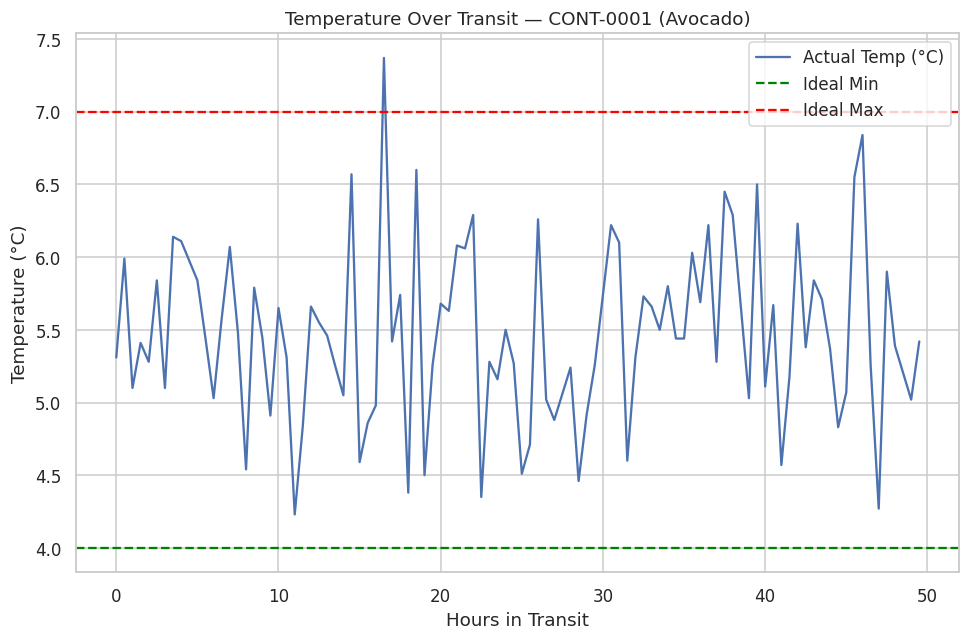

In [30]:
container = df["container_id"].unique()[0]
sub = df[df["container_id"] == container]

plt.figure()
plt.plot(sub["hours_in_transit"], sub["temperature_c"], label="Actual Temp (°C)")
plt.axhline(sub["ideal_temp_min_c"].iloc[0], color="green", ls="--", label="Ideal Min")
plt.axhline(sub["ideal_temp_max_c"].iloc[0], color="red", ls="--", label="Ideal Max")
plt.title(f"Temperature Over Transit — {container} ({sub['commodity'].iloc[0]})")
plt.xlabel("Hours in Transit")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

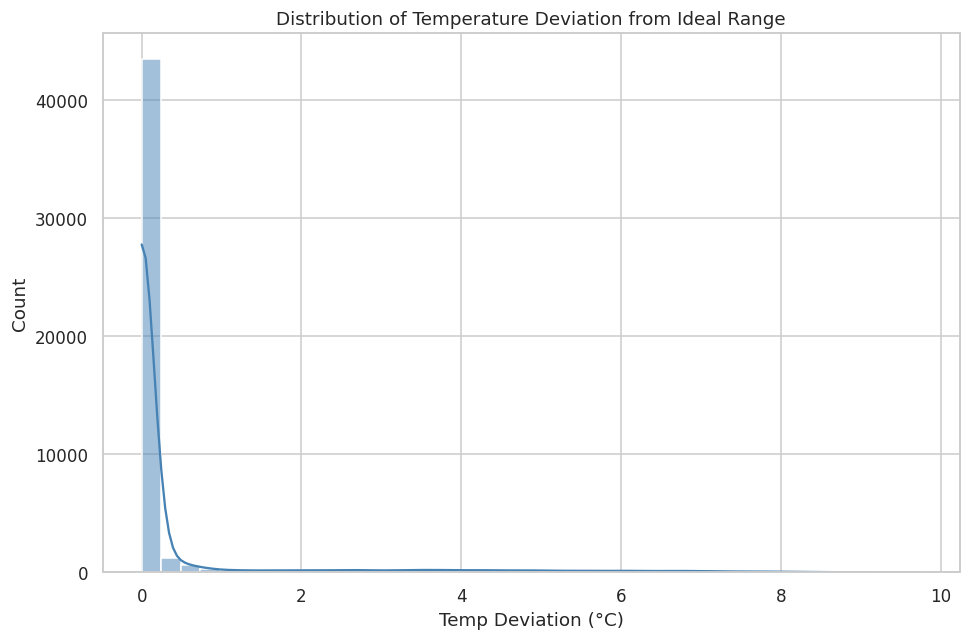

In [31]:
plt.figure()
sns.histplot(df["temp_deviation_c"], kde=True, bins=40, color="steelblue")
plt.title("Distribution of Temperature Deviation from Ideal Range")
plt.xlabel("Temp Deviation (°C)")
plt.tight_layout()
plt.show()

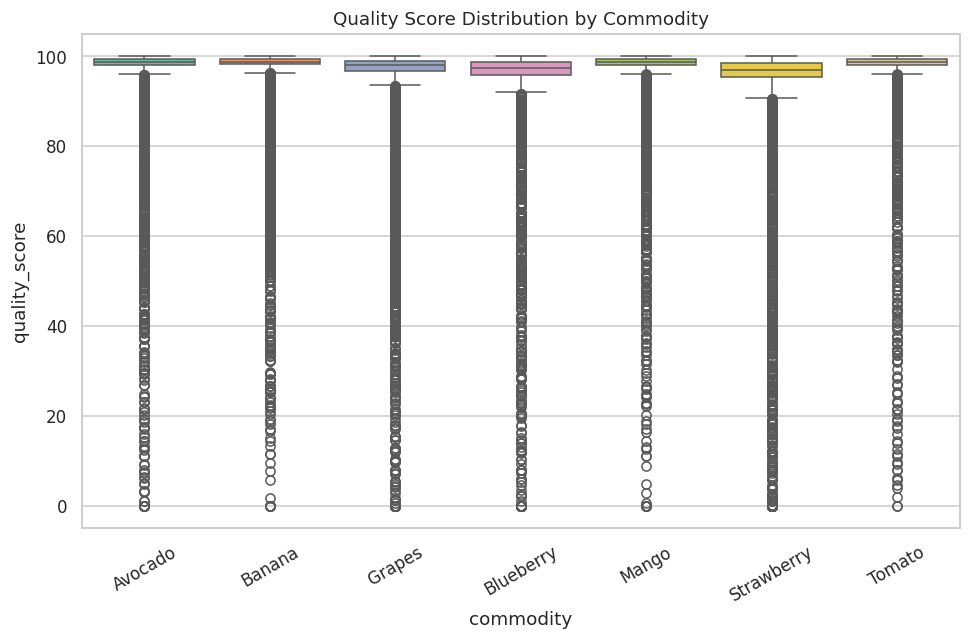

In [32]:
plt.figure()
sns.boxplot(data=df, x="commodity", y="quality_score", hue="commodity",
            palette="Set2", legend=False)
plt.title("Quality Score Distribution by Commodity")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

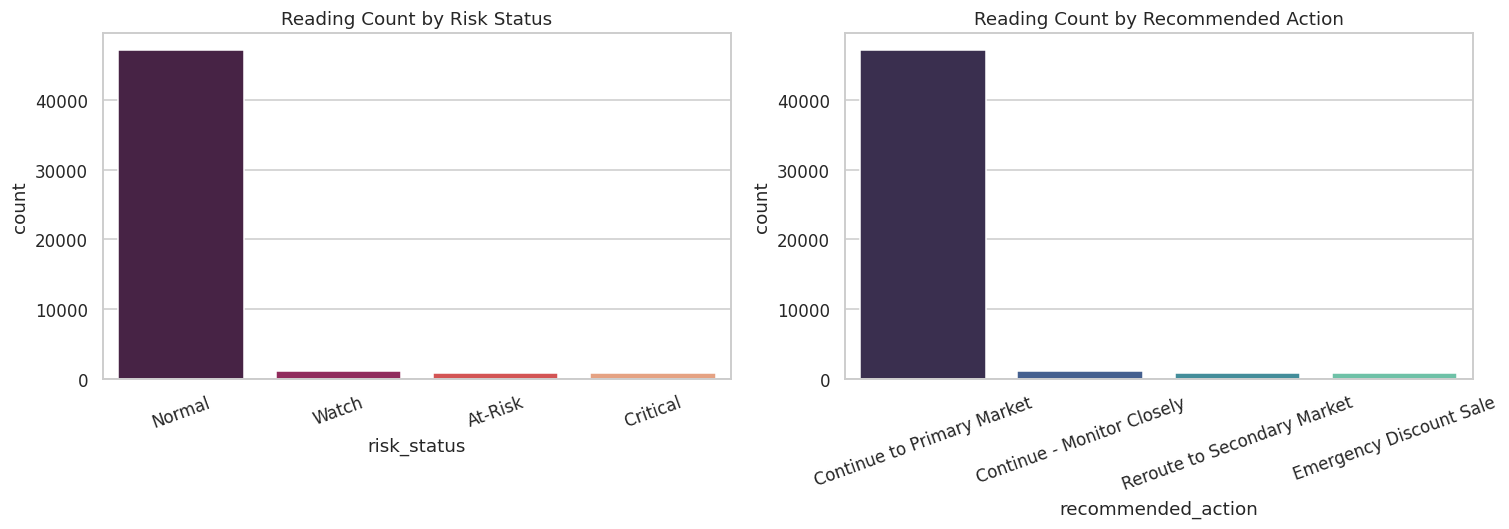

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="risk_status", order=df["risk_status"].value_counts().index,
              ax=axes[0], hue="risk_status", palette="rocket", legend=False)
axes[0].set_title("Reading Count by Risk Status")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="recommended_action",
              order=df["recommended_action"].value_counts().index,
              ax=axes[1], hue="recommended_action", palette="mako", legend=False)
axes[1].set_title("Reading Count by Recommended Action")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

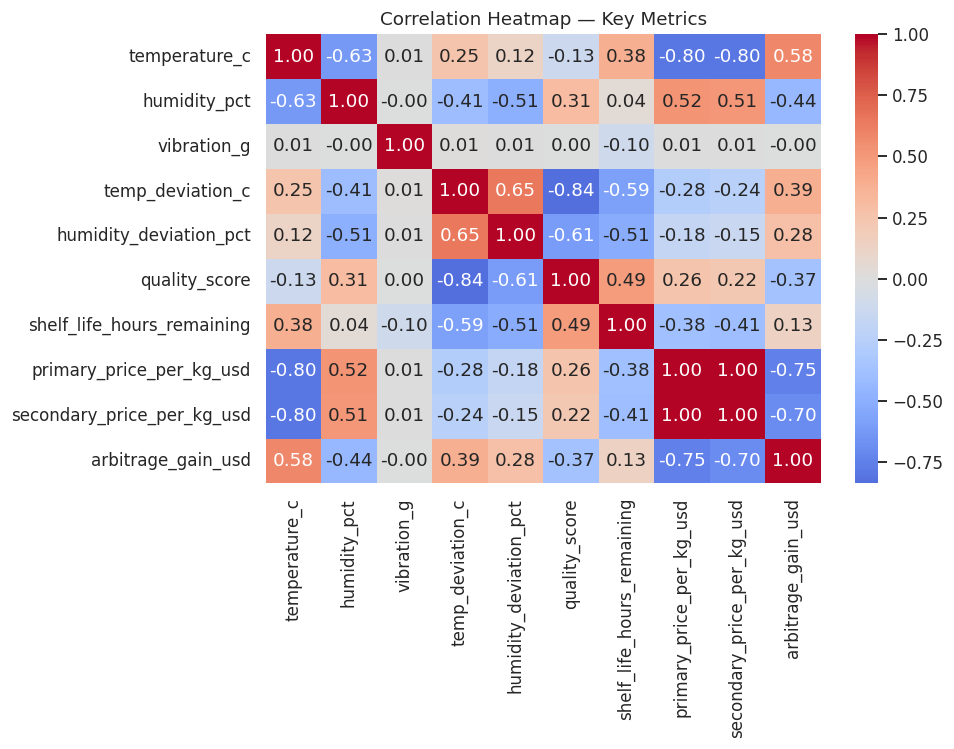

In [34]:
numeric_cols = [
    "temperature_c", "humidity_pct", "vibration_g", "temp_deviation_c",
    "humidity_deviation_pct", "quality_score", "shelf_life_hours_remaining",
    "primary_price_per_kg_usd", "secondary_price_per_kg_usd", "arbitrage_gain_usd",
]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Key Metrics")
plt.tight_layout()
plt.show()